# ML pipeline tittanic (lew1sh)

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold

from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder ,StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import RidgeClassifier



In [2]:
df_train = pd.read_csv('../data/train.csv',sep=',',index_col='PassengerId')
df_test = pd.read_csv('../data/test.csv',sep=',',index_col='PassengerId')

# EDA


In [3]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


In [4]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 418 entries, 892 to 1309
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    418 non-null    int64  
 1   Name      418 non-null    object 
 2   Sex       418 non-null    object 
 3   Age       332 non-null    float64
 4   SibSp     418 non-null    int64  
 5   Parch     418 non-null    int64  
 6   Ticket    418 non-null    object 
 7   Fare      417 non-null    float64
 8   Cabin     91 non-null     object 
 9   Embarked  418 non-null    object 
dtypes: float64(2), int64(3), object(5)
memory usage: 35.9+ KB


In [5]:
df_train.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
num_df = df_train.select_dtypes(include='number')

In [7]:
num_df.columns

Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

In [8]:
for  feature in df_train.columns:
    if not df_train[df_train[feature].isnull()].empty:
        print(f'-----------------{feature}---------')
        print(f'count empty values = {df_train[feature].isnull().sum()}')
        print(f' % empty values = {df_train[feature].isnull().mean()}')

-----------------Age---------
count empty values = 177
 % empty values = 0.19865319865319866
-----------------Cabin---------
count empty values = 687
 % empty values = 0.7710437710437711
-----------------Embarked---------
count empty values = 2
 % empty values = 0.002244668911335578


# пропуски есть в Age, Cabin,Embarked (в Cabin это очень значительно )

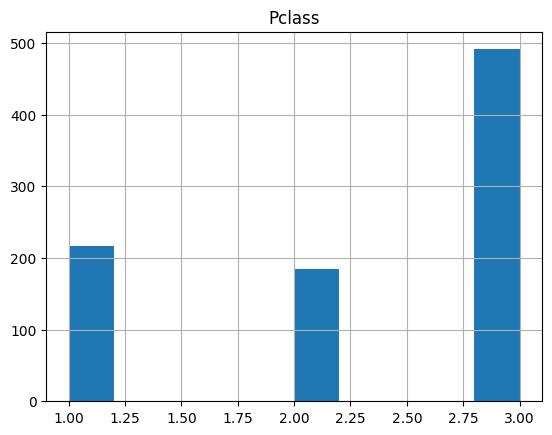

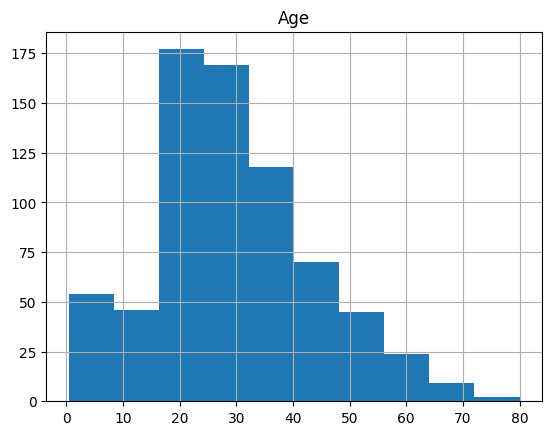

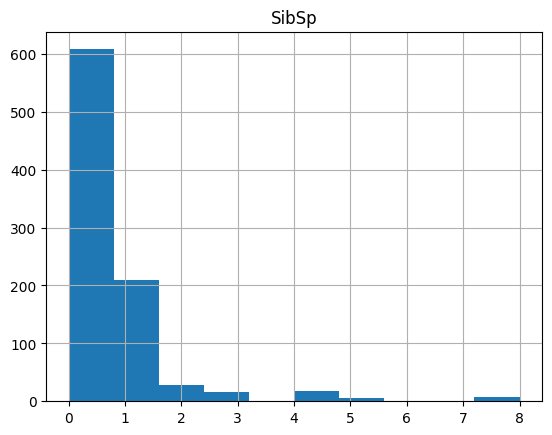

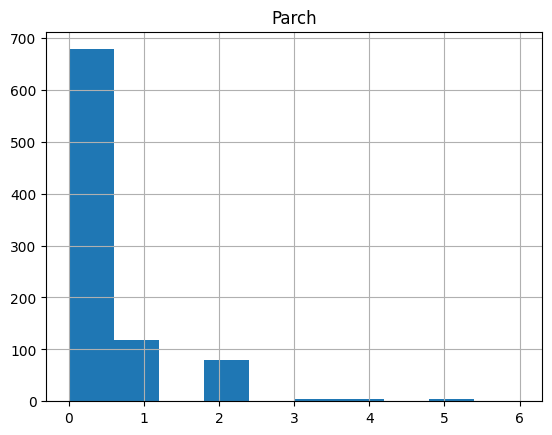

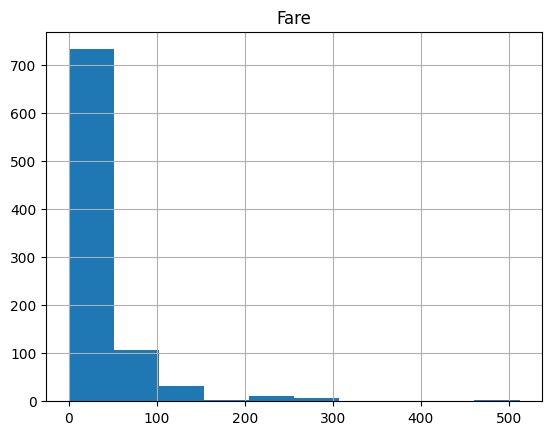

In [9]:

for  feature in num_df.columns[1:]:
    plt.title(feature)
    df_train[feature].hist()
    plt.show()
    

# Выбросы наблюдаются в фичах  parch fare

In [10]:
num_df.columns

Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

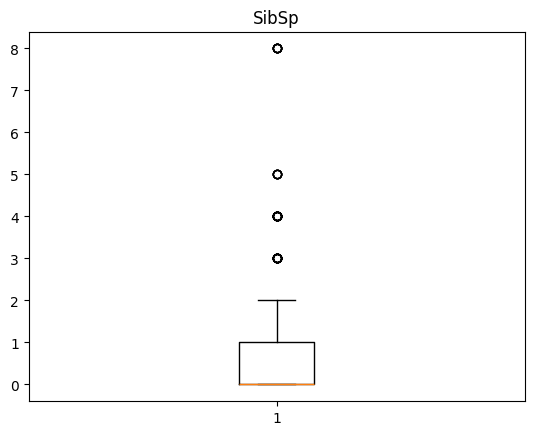

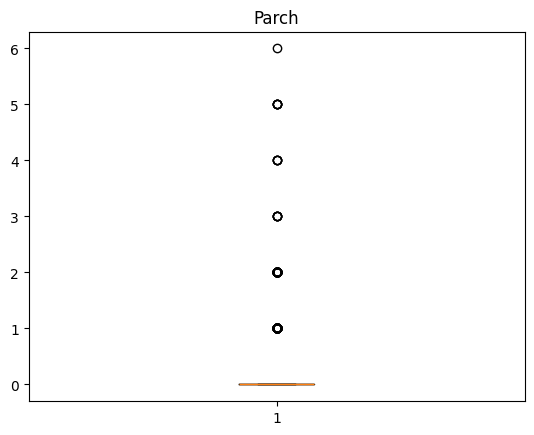

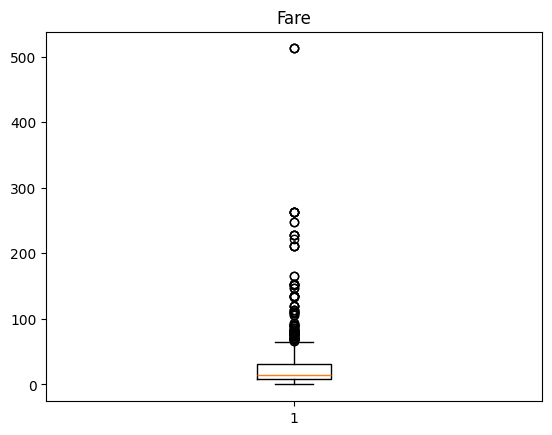

In [11]:
for  feature in [ 'SibSp', 'Parch', 'Fare']:
    plt.title(feature)
    plt.boxplot(df_train[feature])
    #plt.yscale('log')
    plt.show()
    


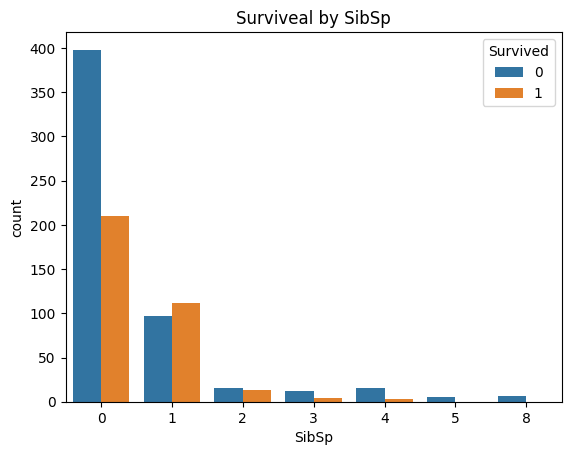

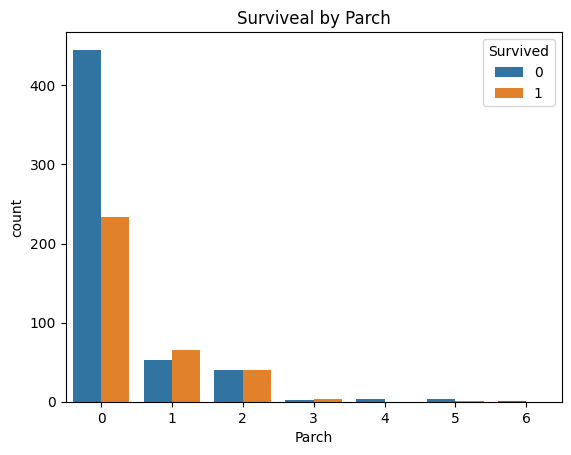

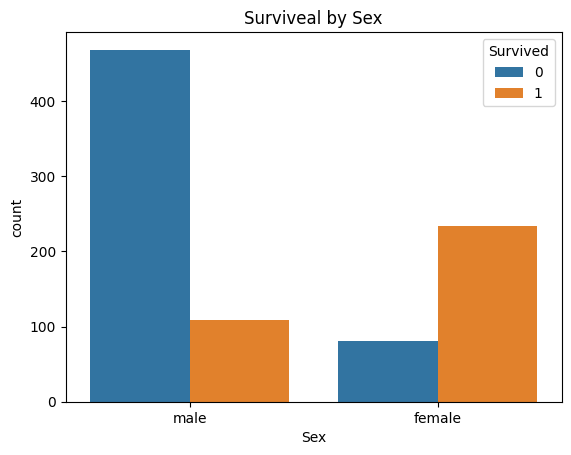

In [12]:
for  feature in [ 'SibSp', 'Parch', 'Sex']:
    plt.title(f'Surviveal by {feature}')
    sns.countplot(data=df_train, x=feature, hue='Survived')
    #plt.yscale('log')
    plt.show()


<Axes: >

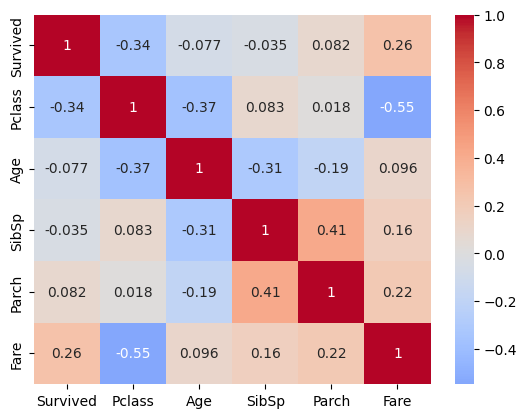

In [13]:
corr_matrix = df_train.corr(numeric_only=True)
sns.heatmap(corr_matrix,annot=True,cmap="coolwarm", center=0)

#### наблюдаются умеренные связи Pclass ~ Fare(отрицательная), sibsp~ Age(отрицательная), Age~Pclass  (отрицательная),Parch~ sibsp

# Cabin availability
Проверяем, связан ли факт наличия каюты с таргетом.


In [ ]:
df_train_eda = df_train.copy()
df_train_eda['HasCabin'] = df_train_eda['Cabin'].notnull().astype(int)
sns.countplot(data=df_train_eda, x='HasCabin', hue='Survived')
plt.title("Survival by Cabin availability")
plt.xlabel("Has Cabin (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()
